Matplotlib is building the font cache; this may take a moment.


  PROJECT 2: DATA CLASSIFICATION USING AI
  DecodeLabs | KNN on Iris Dataset

 STEP 1: Dataset Loaded Successfully!
   Total Samples  : 150
   Total Features : 4
   Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

   First 5 rows:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
               5.1               3.5                1.4               0.2  setosa
               4.9               3.0                1.4               0.2  setosa
               4.7               3.2                1.3               0.2  setosa
               4.6               3.1                1.5               0.2  setosa
               5.0               3.6                1.4               0.2  setosa

   Class Distribution:
species
setosa        50
versicolor    50
virginica     50

 STEP 2: Feature Scaling Done (Mean=0, Variance=1)
   Before: sepal_length range [4.3, 7.9]
   After : sepal_length range [-1.87, 2.49]

 STEP 3: Data Split Do

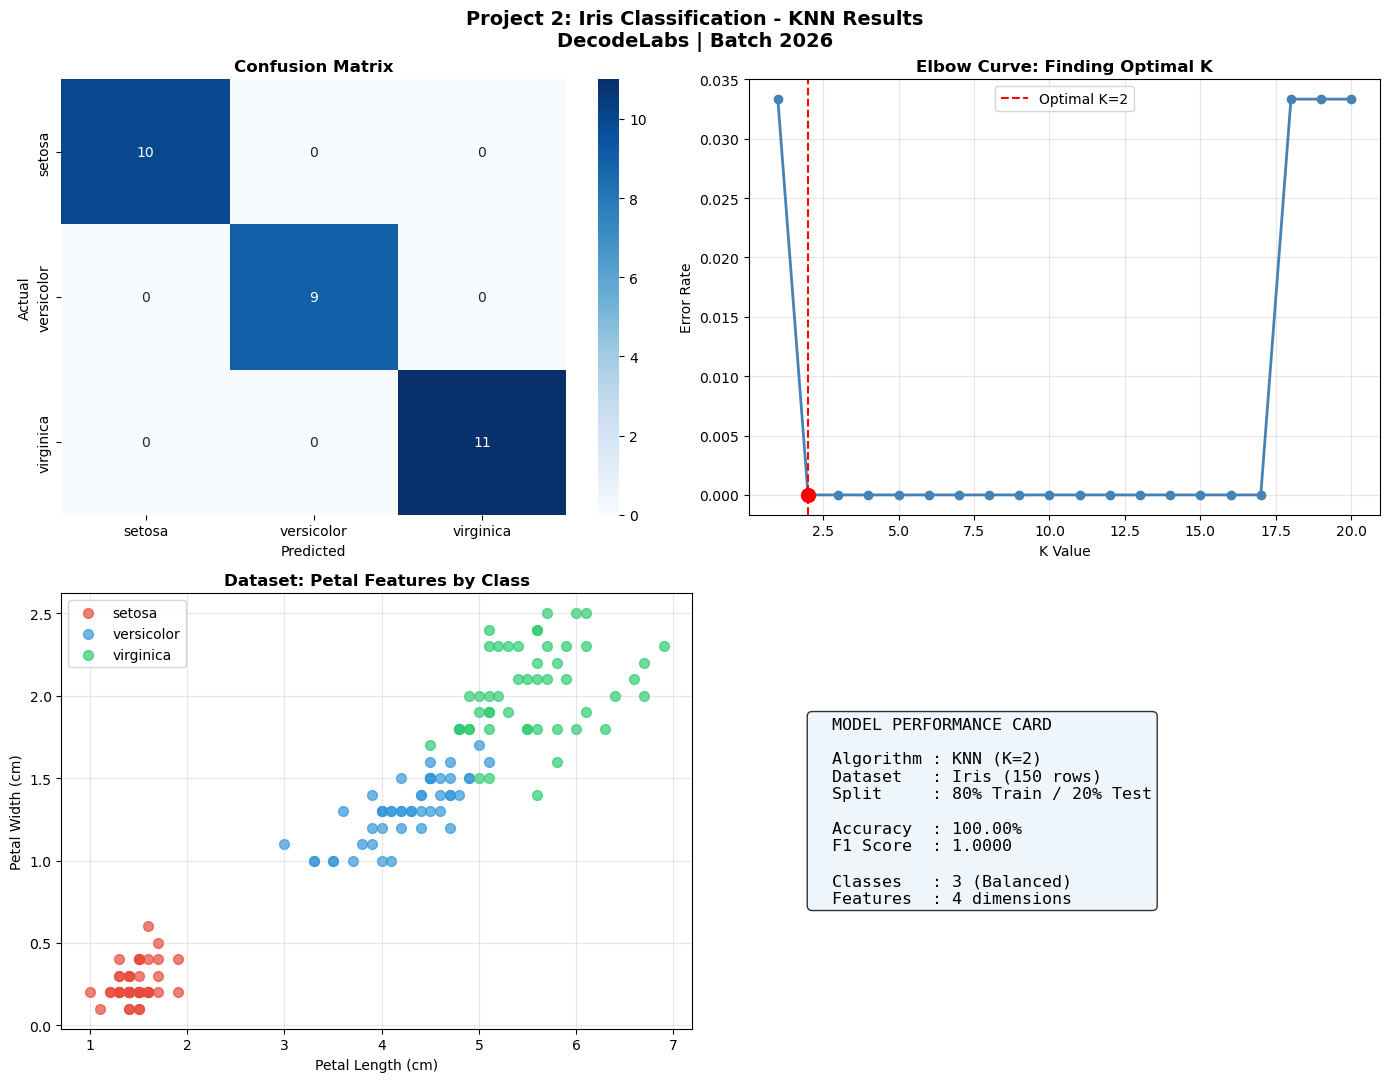


 Visualization saved as project2_results.png

 STEP 7: Predicting on a NEW Custom Sample
   Input    : [5.1, 3.5, 1.4, 0.2]
   Predicted: SETOSA
   Confidence: 100.0%

  PROJECT 2 COMPLETE! Badge Unlocked!


In [1]:
# ============================================================
# PROJECT 2: Data Classification Using AI
# DecodeLabs Industrial Training Kit - Batch 2026
# Algorithm: K-Nearest Neighbors (KNN)
# Dataset: Iris Benchmark
# ============================================================

# STEP 1: IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

print("=" * 55)
print("  PROJECT 2: DATA CLASSIFICATION USING AI")
print("  DecodeLabs | KNN on Iris Dataset")
print("=" * 55)


# STEP 2: LOAD & UNDERSTAND THE DATASET
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("\n STEP 1: Dataset Loaded Successfully!")
print(f"   Total Samples  : {len(df)}")
print(f"   Total Features : {len(iris.feature_names)}")
print(f"   Classes        : {list(iris.target_names)}")
print("\n   First 5 rows:")
print(df.head().to_string(index=False))
print("\n   Class Distribution:")
print(df['species'].value_counts().to_string())


# STEP 3: PREPARE FEATURES & LABELS
X = iris.data
y = iris.target


# STEP 4: FEATURE SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n STEP 2: Feature Scaling Done (Mean=0, Variance=1)")
print(f"   Before: sepal_length range [{X[:,0].min():.1f}, {X[:,0].max():.1f}]")
print(f"   After : sepal_length range [{X_scaled[:,0].min():.2f}, {X_scaled[:,0].max():.2f}]")


# STEP 5: TRAIN-TEST SPLIT (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\n STEP 3: Data Split Done!")
print(f"   Training samples : {len(X_train)} (80%)")
print(f"   Testing  samples : {len(X_test)}  (20%)")


# STEP 6: FIND OPTIMAL K (Elbow Method)
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

optimal_k = k_range[error_rates.index(min(error_rates))]
print(f"\n STEP 4: Optimal K Found = {optimal_k}")


# STEP 7: TRAIN THE KNN MODEL
model = KNeighborsClassifier(n_neighbors=optimal_k)
model.fit(X_train, y_train)
print(f"\n STEP 5: Model Trained with K={optimal_k}")


# STEP 8: MAKE PREDICTIONS
y_pred = model.predict(X_test)


# STEP 9: EVALUATE THE MODEL
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n STEP 6: Model Evaluation Results")
print(f"   Accuracy : {accuracy * 100:.2f}%")
print(f"   F1 Score : {f1:.4f}")
print("\n   Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


# STEP 10: VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Project 2: Iris Classification - KNN Results\nDecodeLabs | Batch 2026",
             fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names, ax=ax1)
ax1.set_title("Confusion Matrix", fontweight='bold')
ax1.set_ylabel("Actual")
ax1.set_xlabel("Predicted")

# Plot 2: Elbow Curve
ax2 = axes[0, 1]
ax2.plot(k_range, error_rates, marker='o', color='steelblue', linewidth=2)
ax2.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
ax2.scatter([optimal_k], [error_rates[optimal_k-1]], color='red', zorder=5, s=100)
ax2.set_title("Elbow Curve: Finding Optimal K", fontweight='bold')
ax2.set_xlabel("K Value")
ax2.set_ylabel("Error Rate")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Petal Feature Distribution
ax3 = axes[1, 0]
colors = ['#e74c3c', '#3498db', '#2ecc71']
for i, (name, color) in enumerate(zip(iris.target_names, colors)):
    mask = iris.target == i
    ax3.scatter(iris.data[mask, 2], iris.data[mask, 3],
                label=name, color=color, alpha=0.7, s=50)
ax3.set_xlabel("Petal Length (cm)")
ax3.set_ylabel("Petal Width (cm)")
ax3.set_title("Dataset: Petal Features by Class", fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Performance Card
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = (
    f"  MODEL PERFORMANCE CARD\n\n"
    f"  Algorithm : KNN (K={optimal_k})\n"
    f"  Dataset   : Iris (150 rows)\n"
    f"  Split     : 80% Train / 20% Test\n\n"
    f"  Accuracy  : {accuracy*100:.2f}%\n"
    f"  F1 Score  : {f1:.4f}\n\n"
    f"  Classes   : 3 (Balanced)\n"
    f"  Features  : 4 dimensions"
)
ax4.text(0.1, 0.5, metrics_text, transform=ax4.transAxes,
         fontsize=12, verticalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#eaf4fb', alpha=0.8))

plt.tight_layout()
plt.savefig("project2_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Visualization saved as project2_results.png")


# STEP 11: PREDICT ON CUSTOM INPUT
print("\n STEP 7: Predicting on a NEW Custom Sample")
custom_sample = [[5.1, 3.5, 1.4, 0.2]]
custom_scaled = scaler.transform(custom_sample)
custom_pred = model.predict(custom_scaled)
custom_prob = model.predict_proba(custom_scaled)

print(f"   Input    : {custom_sample[0]}")
print(f"   Predicted: {iris.target_names[custom_pred[0]].upper()}")
print(f"   Confidence: {max(custom_prob[0])*100:.1f}%")

print("\n" + "=" * 55)
print("  PROJECT 2 COMPLETE! Badge Unlocked!")
print("=" * 55)